In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')

# Load data
print("Loading transaction data...")
train_trans = pd.read_csv('train_transaction.csv')
print(f"Transaction shape: {train_trans.shape}")

print("\nLoading identity data...")
train_id = pd.read_csv('train_identity.csv')
print(f"Identity shape: {train_id.shape}")

Loading transaction data...
Transaction shape: (590540, 394)

Loading identity data...
Identity shape: (144233, 41)


In [2]:
# Basic overview - Transaction
print("=== TRANSACTION DATA ===")
print(f"Rows: {train_trans.shape[0]:,}")
print(f"Columns: {train_trans.shape[1]}")
print(f"\nFraud distribution:")
print(train_trans['isFraud'].value_counts())
print(f"\nFraud rate: {train_trans['isFraud'].mean()*100:.2f}%")

print("\n=== MISSING VALUES (Top 20) ===")
missing = train_trans.isnull().sum()
missing_pct = (missing / len(train_trans) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
print(missing_df[missing_df['Missing'] > 0].sort_values('Pct', ascending=False).head(20))

=== TRANSACTION DATA ===
Rows: 590,540
Columns: 394

Fraud distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.50%

=== MISSING VALUES (Top 20) ===
       Missing    Pct
dist2   552913  93.63
D7      551623  93.41
D13     528588  89.51
D14     528353  89.47
D12     525823  89.04
D6      517353  87.61
D8      515614  87.31
D9      515614  87.31
V163    508595  86.12
V166    508589  86.12
V165    508589  86.12
V164    508589  86.12
V147    508595  86.12
V142    508595  86.12
V141    508595  86.12
V140    508595  86.12
V139    508595  86.12
V150    508589  86.12
V149    508595  86.12
V148    508595  86.12


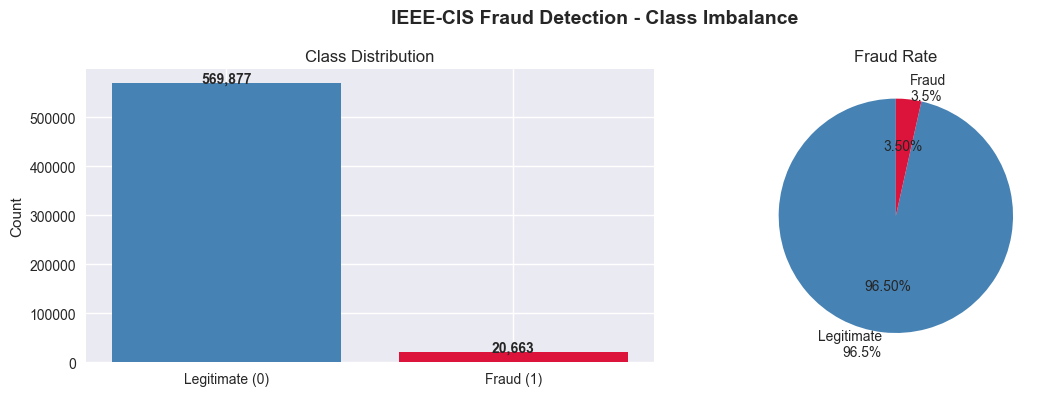

Saved: 01_class_distribution.png


In [3]:
# Fraud distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Class distribution
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], 
            train_trans['isFraud'].value_counts().values,
            color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(train_trans['isFraud'].value_counts().values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Fraud rate
axes[1].pie([569877, 20663], 
            labels=['Legitimate\n96.5%', 'Fraud\n3.5%'],
            colors=['steelblue', 'crimson'],
            autopct='%1.2f%%',
            startangle=90)
axes[1].set_title('Fraud Rate')

plt.suptitle('IEEE-CIS Fraud Detection - Class Imbalance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_class_distribution.png")

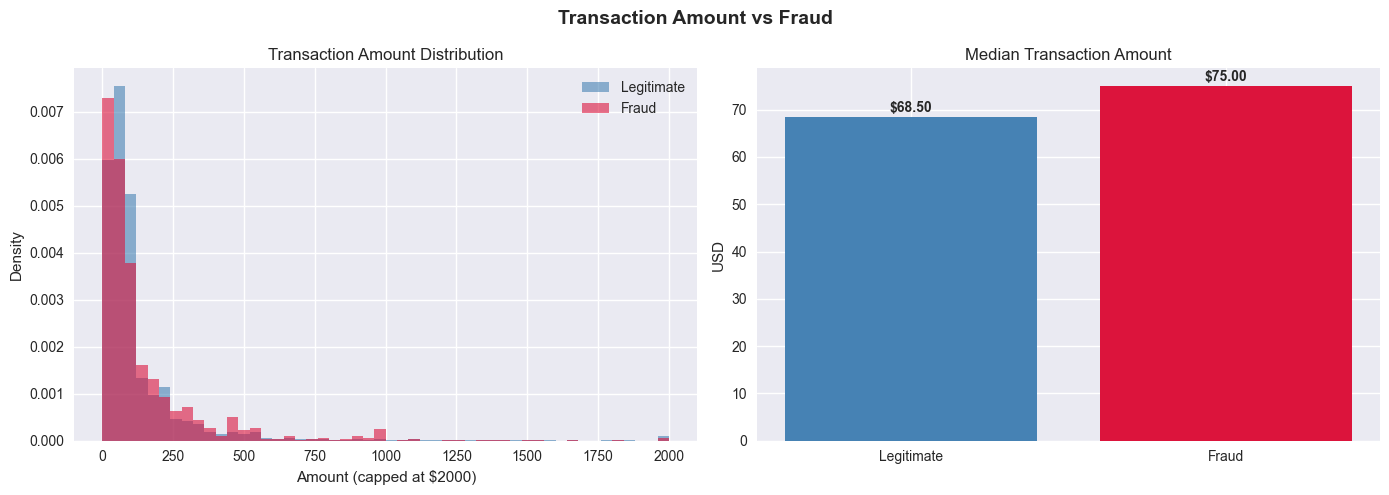

Legitimate - Mean: $134.51, Median: $68.50, Max: $31937.39
Fraud      - Mean: $149.24, Median: $75.00, Max: $5191.00


In [4]:
# Transaction Amount Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Amount distribution by fraud
fraud = train_trans[train_trans['isFraud'] == 1]['TransactionAmt']
legit = train_trans[train_trans['isFraud'] == 0]['TransactionAmt']

axes[0].hist(legit.clip(upper=2000), bins=50, alpha=0.6, color='steelblue', label='Legitimate', density=True)
axes[0].hist(fraud.clip(upper=2000), bins=50, alpha=0.6, color='crimson', label='Fraud', density=True)
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (capped at $2000)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plot 2: Median amount by fraud
axes[1].bar(['Legitimate', 'Fraud'],
            [legit.median(), fraud.median()],
            color=['steelblue', 'crimson'])
axes[1].set_title('Median Transaction Amount')
axes[1].set_ylabel('USD')
for i, v in enumerate([legit.median(), fraud.median()]):
    axes[1].text(i, v + 1, f'${v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Transaction Amount vs Fraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Legitimate - Mean: ${legit.mean():.2f}, Median: ${legit.median():.2f}, Max: ${legit.max():.2f}")
print(f"Fraud      - Mean: ${fraud.mean():.2f}, Median: ${fraud.median():.2f}, Max: ${fraud.max():.2f}")

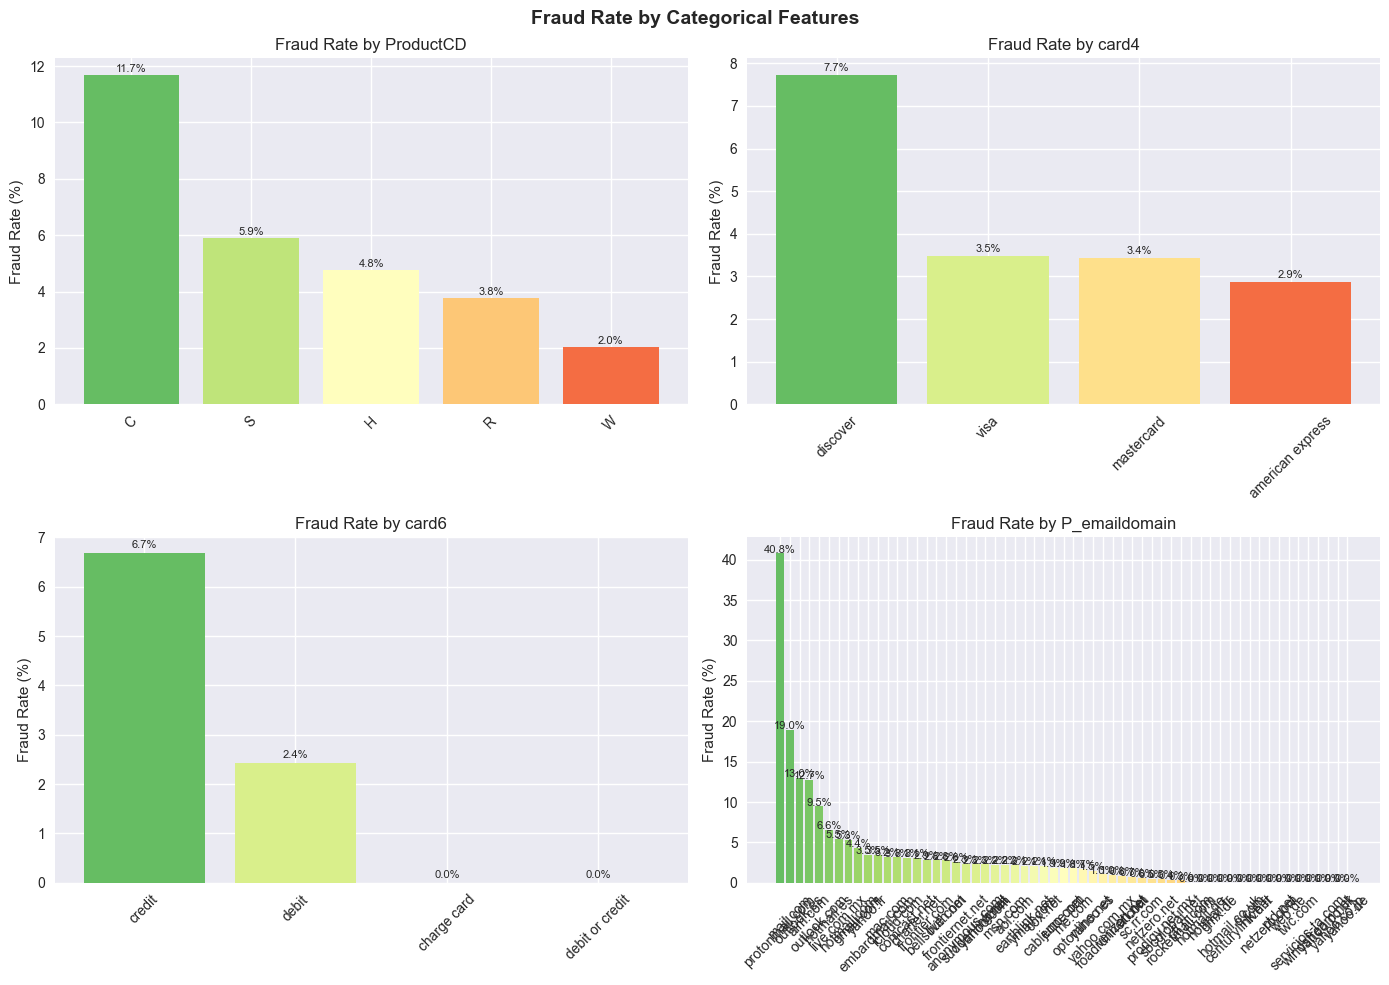

In [5]:
# Categorical Features Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cat_features = ['ProductCD', 'card4', 'card6', 'P_emaildomain']

for ax, col in zip(axes.flatten(), cat_features):
    fraud_rate = train_trans.groupby(col)['isFraud'].mean().sort_values(ascending=False)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(fraud_rate)))
    bars = ax.bar(fraud_rate.index.astype(str), fraud_rate.values * 100, color=colors)
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate (%)')
    ax.tick_params(axis='x', rotation=45)
    for bar, v in zip(bars, fraud_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{v*100:.1f}%', ha='center', fontsize=8)

plt.suptitle('Fraud Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Merging datasets...
Merged shape: (590540, 434)
Identity match rate: 24.4%


C:\Users\alike\AppData\Local\Temp\ipykernel_17036\3880431487.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
C:\Users\alike\AppData\Local\Temp\ipykernel_17036\3880431487.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hour'] = (df['TransactionDT'] / 3600 % 24).astype(int)
C:\Users\alike\AppData\Local\Temp\ipykernel_17036\3880431487.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whic

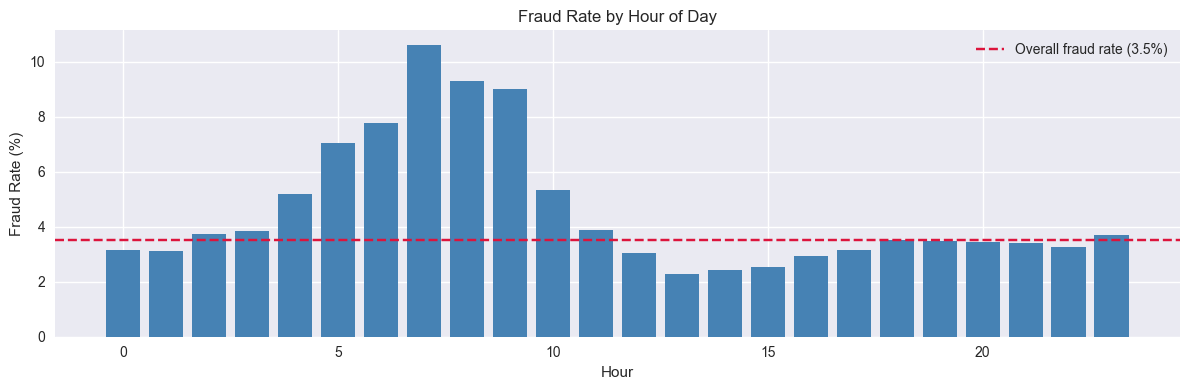


Peak fraud hour: 7:00 (10.6%)
Lowest fraud hour: 13:00 (2.3%)


In [6]:
# Merge transaction + identity
print("Merging datasets...")
df = train_trans.merge(train_id, on='TransactionID', how='left')
print(f"Merged shape: {df.shape}")
print(f"Identity match rate: {df['id_01'].notna().mean()*100:.1f}%")

# Log transform TransactionAmt
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])

# Transaction hour/day from TransactionDT
df['hour'] = (df['TransactionDT'] / 3600 % 24).astype(int)
df['day'] = (df['TransactionDT'] / (3600*24) % 7).astype(int)

# Fraud rate by hour
plt.figure(figsize=(12, 4))
hourly_fraud = df.groupby('hour')['isFraud'].mean() * 100
plt.bar(hourly_fraud.index, hourly_fraud.values, color='steelblue')
plt.axhline(y=3.5, color='crimson', linestyle='--', label='Overall fraud rate (3.5%)')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('04_hourly_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPeak fraud hour: {hourly_fraud.idxmax()}:00 ({hourly_fraud.max():.1f}%)")
print(f"Lowest fraud hour: {hourly_fraud.idxmin()}:00 ({hourly_fraud.min():.1f}%)")

In [7]:
# Defragment dataframe
df = df.copy()
print("Defragmented. Shape:", df.shape)

# EDA Summary
print("\n=== EDA SUMMARY ===")
print(f"Total transactions: {len(df):,}")
print(f"Fraud cases: {df['isFraud'].sum():,} ({df['isFraud'].mean()*100:.2f}%)")
print(f"Identity match rate: {df['id_01'].notna().mean()*100:.1f}%")
print(f"Features: {df.shape[1]}")
print(f"\nKey Risk Drivers identified:")
print(f"  - ProductCD 'C': {df[df['ProductCD']=='C']['isFraud'].mean()*100:.1f}% fraud rate")
print(f"  - card6 'credit': {df[df['card6']=='credit']['isFraud'].mean()*100:.1f}% fraud rate")
print(f"  - Peak fraud hour (07:00): ~10.6%")
print(f"  - protonmail.com email: ~40.8% fraud rate")
print(f"\nClass imbalance ratio: 1:{int(df['isFraud'].value_counts()[0]/df['isFraud'].value_counts()[1])}")
print("\nEDA complete. Ready for Feature Engineering.")

Defragmented. Shape: (590540, 437)

=== EDA SUMMARY ===
Total transactions: 590,540
Fraud cases: 20,663 (3.50%)
Identity match rate: 24.4%
Features: 437

Key Risk Drivers identified:
  - ProductCD 'C': 11.7% fraud rate
  - card6 'credit': 6.7% fraud rate
  - Peak fraud hour (07:00): ~10.6%
  - protonmail.com email: ~40.8% fraud rate

Class imbalance ratio: 1:27

EDA complete. Ready for Feature Engineering.
